# ZXZ - Y mps optimization sweep

Created: 13-07-2026

Objectives:
* Apply [mps optimization](random_fdlu_noising_mps_optimization_sweep.ipynb) to [ZXZ - Y](quspin_zxz_y_rdm_tensor_network_factorization.ipynb) states.
* May be trickier numerically, as now we have to use a full ED state.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [54]:
import pickle

# Definitions

In [10]:
num_sites = 16

In [11]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [12]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=10):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [13]:
parameters = np.linspace(0, 1, 201)

In [14]:
hamiltonians = [
    get_hamiltoniain(p, num_sites)
    for p in parameters
]

In [15]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')
    energies.append(e)
    groundstates.append(psi)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [03:07<00:00,  1.07it/s]


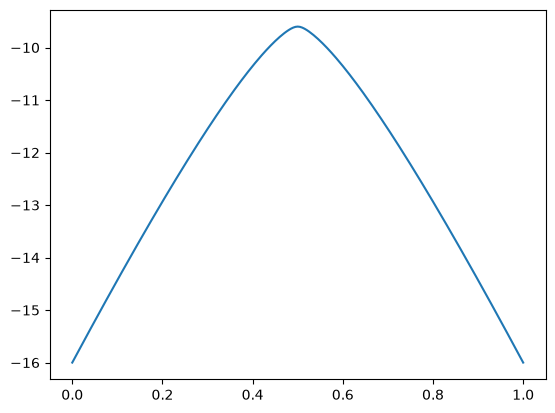

In [16]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [17]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [18]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [19]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

In [20]:
np_I = np.array([
    [1,0],
    [0,1]
])

In [21]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='I'
)

In [22]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [23]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

## Defect operators

In [24]:
# I don't think we're using this anymore
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [25]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [26]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [27]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [28]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [29]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [30]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [31]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [32]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=2000)

    return A_opt, tnopt.losses, tnopt.loss_best

In [33]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [34]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [35]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['left_defect_sites']
    ]

    central_gates = [
        qu_X.reindex({'k': f'k{i}', 'b':f'b{i}'})
        for i in central_sites
    ]

    right_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['right_defect_sites']
    ]

    all_tensors = [
        rho_tilde.reindex(
            {f'b{i}': f'i{i}' for i in domains_dict['left_defect_sites']}
            | {f'b{i}': f'i{i}' for i in domains_dict['right_defect_sites']}
        ),
        *left_gates,
        *central_gates,
        *right_gates
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        qtn.TensorNetwork(all_tensors)
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [36]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl': 'ki2', 'kl': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br': 'ki2', 'kr': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        overlap
    )

    return out

In [37]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [38]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [39]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

## Apply random unitary to groundstate

In [40]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [41]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

# Sweep

In [42]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10, 11],
    'fdlu_depth': 0,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [43]:
results = list()

for psi in tqdm(groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=[f'k{i}' for i in range(domains_dict['num_system_sites'])]
    )
    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    results.append(defect_opt_out)

  0%|                                                                                                                                                                    | 0/201 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [24:19<00:00,  7.26s/it]


In [44]:
results[0]

(array([9.93872599e-01, 2.01339800e-08, 2.01253162e-08, 2.69835333e-10,
        2.64991070e-10]),
 Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('kr', 'br'), tags=oset([])),
 np.complex128(0.9999999999999994-2.4091839634365897e-13j),
 np.complex128(0.9999999999961774-5.763260979563256e-10j),
 [np.float64(0.16044440988575145),
  np.float64(0.9939535969989199),
  np.float64(0.9939535969989272),
  np.float64(0.9939535969989273),
  np.float64(0.9939535969989267),
  np.float64(0.9939535969989272),
  np.float64(0.9939535969989267),
  np.float64(0.9939535969989275),
  np.float64(0.9939535969989268),
  np.float64(0.9939535969989274),
  np.float64(0.9939535969989268),
  np.float64(0.9939535969989272),
  np.float64(0.9939535969989272),
  np.float64(0.9939535969989268),
  np.float64(0.993953596998927),
  np.float64(0.9939535969989273),
  np.float64(0.9939535969989269),
  np.float64(0.9939535969989275),
  np.float64(0.9939535969989266),
  np.float64(0.99395359

In [45]:
results[-1]

(array([2.49948146e-01, 1.74071527e-05, 8.93131856e-06, 9.54753699e-07,
        2.66437136e-08, 1.82112445e-08, 1.38755123e-08, 1.63478749e-09,
        8.19352492e-10, 3.61275974e-10, 3.41766575e-10, 6.34203275e-11,
        5.64925242e-11]),
 Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999999999987+0j),
 np.complex128(-0.9999999999999821+2.7755575615628914e-17j),
 [np.float64(0.898170555976975),
  np.float64(0.9997925723113339),
  np.float64(0.9997925740493311),
  np.float64(0.9997925740493309),
  np.float64(0.9997925740493316),
  np.float64(0.999792574049331),
  np.float64(0.999792574049331),
  np.float64(0.9997925740493308),
  np.float64(0.9997925740493313),
  np.float64(0.9997925740493314),
  np.float64(0.9997925740493311),
  np.float64(0.9997925740493316),
  np.float64(0.9997925740493312),
  np.float64(0.9997925740493314),
  np.float64(0.9997925740493316),
  np.float64(0.9997925740493316),
  

In [46]:
overlaps = [l[-1] for l in results]

In [47]:
pd.Series(overlaps).describe()

count    201.000000
mean       0.946820
std        0.098946
min        0.358976
25%        0.945722
50%        0.986027
75%        0.995775
max        0.999858
dtype: float64

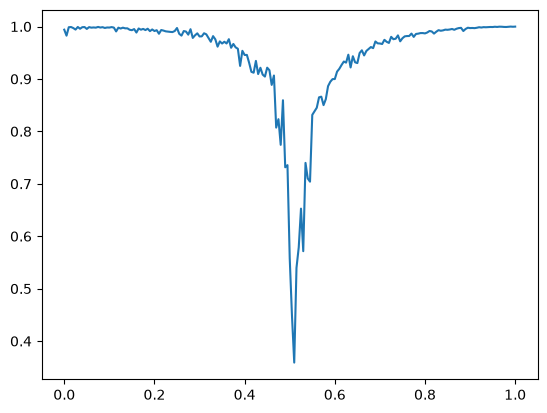

In [52]:
plt.plot(parameters, overlaps)

In [48]:
indices = np.array([l[3:5] for l in results])

In [49]:
np.max(np.abs(np.imag(indices)))

np.float64(0.004508037714264612)

In [50]:
indices = np.real(indices)

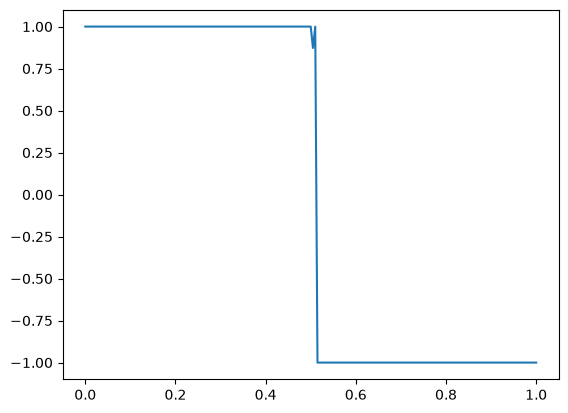

In [53]:
plt.plot(parameters, indices[:, 0])

In [56]:
with open(r'../../make_plots/data/zxz_y_trs_defect_operators/results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Conclusions
Looks good.